# AI4I 2020 Dataset — Exploratory Data Analysis

> Industrial predictive maintenance dataset — 10,000 data points
> from a simulated milling machine.

**Objective:** Understand the distribution of variables and failure modes
before building the ML model.

**Source:** S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications", AI4I 2020.

## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## 2. Data Loading

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

## 3. Shape Analysis

In [27]:
print("Shape :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nTypes :\n", df.dtypes)
df.head()

Shape : (10000, 14)

Colonnes : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Types :
 UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 4. Descriptive Statistics

In [28]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 5. Missing Values

In [29]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

## 6. Failure rate

In [30]:
print(f"Pannes : {df['Machine failure'].sum()} / {len(df)} ({df['Machine failure'].mean()*100:.2f}%)")

Pannes : 339 / 10000 (3.39%)


## 7. Visualizations

### Target feature distribution (Machine failure)

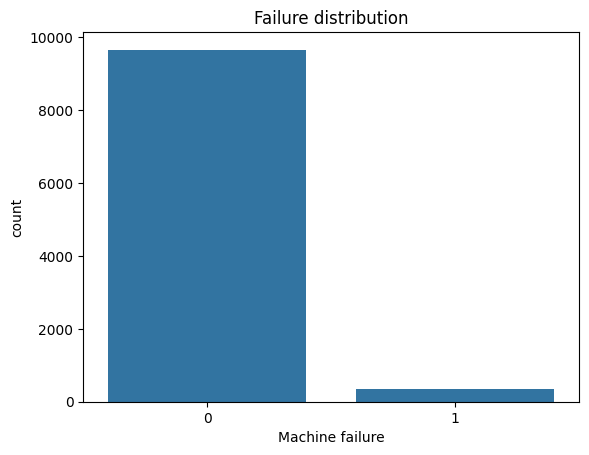

In [31]:
sns.countplot(x='Machine failure', data=df)
plt.title('Failure distribution')
plt.show()


### Correlation heatmap

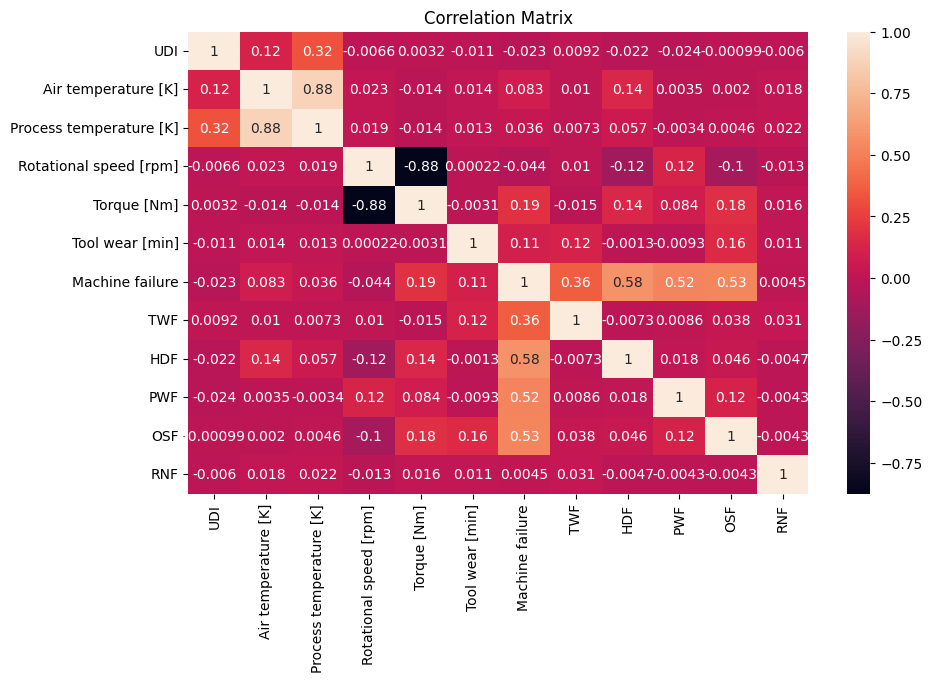

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True) 
plt.title('Correlation Matrix')
plt.show()

### Machine Type Distribution

In [33]:
fig = px.pie(df, names='Type', title='Machine types distribution')
fig.show()
fig.write_image("../outputs/distribution_types.png")

### Failure Rate by Machine Type

In [34]:
fig = px.bar(
    df.groupby('Type')['Machine failure'].mean().reset_index(),
    x='Type', y='Machine failure',
    title='Failure Rate by Machine Type',
    labels={'Machine failure': 'Failure rate'},
    color='Type'
)
fig.show()
fig.write_image("../outputs/failure_rate.png")

### Failure Modes

In [35]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
counts = df[failure_modes].sum().reset_index()
counts.columns = ['Mode', 'Number']

fig = px.bar(counts, x='Mode', y='Number',
    title='Number of cases by type of failure',
    color='Mode')
fig.show()
fig.write_image("../outputs/failure_modes.png")

### Correlation Matrix with plotly

In [36]:
fig = px.imshow(
    df.select_dtypes(include='number').corr().round(2),
    title='Correlation Matrix',
    text_auto=True,
    color_continuous_scale='RdBu_r'
)
fig.show()
fig.write_image("../outputs/correlation.png")

## 8. Key Findings

### Dataset Structure
- **10,000 rows, 14 columns** — clean dataset, no missing values
- Columns `UDI` and `Product ID` will be dropped during preprocessing (no ML value)
- Column `Type` (L/M/H) will be numerically encoded for the model

### Machine Type Distribution
- **60% type L** (Low quality), 30% M, 10% H
- Imbalanced distribution across machine types — to consider in the model

### Failures — Highly Imbalanced Dataset
- Only **~3.4% failures** out of 10,000 observations (~339 cases)
- Classic **class imbalance** problem → techniques like SMOTE,
  class_weight or adjusted decision threshold will be needed

### Failure Modes
| Mode | Cases | Description |
|------|-------|-------------|
| HDF | 115 | Insufficient heat dissipation |
| TWF | 120 | Excessive tool wear |
| OSF | 98  | Tool overstrain |
| PWF | 95  | Power out of range |
| RNF | 5   | Random failure (unpredictable) |

- **RNF is unpredictable** by nature → to be excluded or handled separately
- Failure modes can **overlap** on the same data point

### Key Correlations
- `Torque` and `Rotational speed` are **strongly negatively correlated** (~-0.88)
  → physically consistent : power = torque × speed
- `Tool wear` correlates with `OSF` and `TWF` → highly predictive feature
- `Air temperature` and `Process temperature` are **highly correlated** (~0.88)
  → candidate for feature engineering : `delta_temperature`

### Feature Engineering Plan
- `delta_temperature` = Process temp − Air temp (key for HDF)
- `power` = Torque × Rotational speed × (2π/60) (key for PWF)
- `tool_wear_torque` = Tool wear × Torque (key for OSF)
- Encode `Type` : L→0, M→1, H→2

### ML Strategy
- **Main objective** : binary classification `Machine failure` (0/1)
- **Secondary objective** : multi-label classification of the 5 failure modes
- Algorithms to test : Random Forest, XGBoost, then maybe PyTorch neural network
- **Main metric : F1-score** (not accuracy — imbalanced dataset)